In [1]:
import pandas as pd
import numpy as np

In [2]:
employees = pd.read_excel("HR_Analytics_Uncleaned_Dataset.xlsx",sheet_name = "Employees")
attendance = pd.read_excel("HR_Analytics_Uncleaned_Dataset.xlsx",sheet_name = "Attendance")
performance = pd.read_excel("HR_Analytics_Uncleaned_Dataset.xlsx",sheet_name = "Performance")


In [3]:
employees.head()

,EmployeeID,Name,Department,JobRole,HireDate,Gender,Salary,ManagerID,Email
0,1,Employee 1,HR,Analyst,2018-03-22,M,80505,38,emp1@company.com
1,2,Employee 2,HR,Associate,2023-10-16,F,77368,29,emp2@company.com
2,3,Employee 3,IT,Analyst,2023-07-09,M,33198,63,emp3@company.com
3,4,Employee 4,Sales,Analyst,2022-12-18,M,87655,78,emp4@company.com
4,5,Employee 5,Finance,Executive,2022-05-24,F,28962,13,emp5@company.com


In [4]:
attendance.head()

,AttendanceID,EmployeeID,Date,Status,WorkHours
0,1,37,12/05/2025,WFH,7.7
1,2,412,01/02/2025,Leave,NaN
2,3,865,13/01/2025,Present,8.8
3,4,200,02/06/2025,WFH,6.0
4,5,725,23/02/2025,Present,9.6


In [5]:
performance.head()

,ReviewID,EmployeeID,ReviewDate,PerformanceScore,TrainingHours,Promotion,Attrition
0,1,1,2025-06-30,5.0,23,Yes,No
1,2,2,2025-06-30,NaN,61,No,No
2,3,3,2025-06-30,5.0,75,Yes,No
3,4,4,2025-06-30,1.0,65,No,No
4,5,5,2025-06-30,2.0,7,Yes,Yes


In [6]:
# describe employees data
employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   EmployeeID  1001 non-null   int64 
 1   Name        1001 non-null   object
 2   Department  1001 non-null   object
 3   JobRole     1001 non-null   object
 4   HireDate    1001 non-null   object
 5   Gender      1001 non-null   object
 6   Salary      1001 non-null   int64 
 7   ManagerID   1001 non-null   int64 
 8   Email       954 non-null    object
dtypes: int64(3), object(6)
memory usage: 70.5+ KB


In [7]:
employees.describe()

,EmployeeID,Salary,ManagerID
count,1001.000000,1001.000000,1001.000000
mean,500.004995,87641.604396,50.342657
std,289.099507,35586.909360,29.060342
min,1.000000,25008.000000,1.000000
25%,250.000000,58423.000000,24.000000
50%,500.000000,86991.000000,51.000000
75%,750.000000,118736.000000,76.000000
max,1000.000000,149942.000000,100.000000


In [8]:
# column name
employees.columns

Index(['EmployeeID', 'Name', 'Department', 'JobRole', 'HireDate', 'Gender',
       'Salary', 'ManagerID', 'Email'],
      dtype='object')

In [9]:
# check null values if existis
employees.isnull().sum()

EmployeeID     0
Name           0
Department     0
JobRole        0
HireDate       0
Gender         0
Salary         0
ManagerID      0
Email         47
dtype: int64

In [10]:
employees.columns

Index(['EmployeeID', 'Name', 'Department', 'JobRole', 'HireDate', 'Gender',
       'Salary', 'ManagerID', 'Email'],
      dtype='object')

In [11]:
# delete email column if not required
employees.drop("Email",axis = 1 , inplace = True)

In [12]:
# check datatypes
employees.dtypes

EmployeeID     int64
Name          object
Department    object
JobRole       object
HireDate      object
Gender        object
Salary         int64
ManagerID      int64
dtype: object

In [13]:
# convert data type of HireDate column to date
employees["HireDate"] = pd.to_datetime(employees["HireDate"])

In [14]:
# check data types after formatting
employees.dtypes

EmployeeID             int64
Name                  object
Department            object
JobRole               object
HireDate      datetime64[ns]
Gender                object
Salary                 int64
ManagerID              int64
dtype: object

In [15]:
# check duplicates
employees["EmployeeID"].duplicated().sum()

np.int64(1)

In [16]:
# remove duplicate based on primary key column
employees.drop_duplicates(subset = ["EmployeeID"],inplace=True)

In [17]:
# check duplicates after removes duplicates
employees["EmployeeID"].duplicated().sum()

np.int64(0)

In [18]:
# understand attendance table
attendance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AttendanceID  8000 non-null   int64  
 1   EmployeeID    8000 non-null   int64  
 2   Date          8000 non-null   object 
 3   Status        8000 non-null   object 
 4   WorkHours     7769 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 312.6+ KB


In [19]:
attendance.describe()

,AttendanceID,EmployeeID,WorkHours
count,8000.00000,8000.000000,7769.000000
mean,4000.50000,502.234625,7.006835
std,2309.54541,288.866841,1.724194
min,1.00000,1.000000,4.000000
25%,2000.75000,250.000000,5.500000
50%,4000.50000,502.000000,7.000000
75%,6000.25000,754.000000,8.500000
max,8000.00000,1000.000000,10.000000


In [20]:
# check null values
attendance.isnull().sum()

AttendanceID      0
EmployeeID        0
Date              0
Status            0
WorkHours       231
dtype: int64

In [21]:
# fill null values
attendance["WorkHours"] = attendance["WorkHours"].fillna(attendance["WorkHours"].mean())

In [22]:
# after fill null values check dataset
attendance.isnull().sum()

AttendanceID    0
EmployeeID      0
Date            0
Status          0
WorkHours       0
dtype: int64

In [23]:
# check data types
attendance.dtypes

AttendanceID      int64
EmployeeID        int64
Date             object
Status           object
WorkHours       float64
dtype: object

In [24]:
# convert Date column to datetime formate
attendance["Date"] = pd.to_datetime(attendance["Date"],dayfirst= True)

In [25]:
attendance.dtypes

AttendanceID             int64
EmployeeID               int64
Date            datetime64[ns]
Status                  object
WorkHours              float64
dtype: object

In [26]:
# check duplicate based on AttendanceID
attendance["AttendanceID"].nunique()

8000

In [27]:
# understand Performance table
performance.head()

,ReviewID,EmployeeID,ReviewDate,PerformanceScore,TrainingHours,Promotion,Attrition
0,1,1,2025-06-30,5.0,23,Yes,No
1,2,2,2025-06-30,NaN,61,No,No
2,3,3,2025-06-30,5.0,75,Yes,No
3,4,4,2025-06-30,1.0,65,No,No
4,5,5,2025-06-30,2.0,7,Yes,Yes


In [28]:
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ReviewID          1000 non-null   int64  
 1   EmployeeID        1000 non-null   int64  
 2   ReviewDate        1000 non-null   object 
 3   PerformanceScore  860 non-null    float64
 4   TrainingHours     1000 non-null   int64  
 5   Promotion         1000 non-null   object 
 6   Attrition         1000 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 54.8+ KB


In [29]:
# check duplicates values
performance.duplicated().sum()

np.int64(0)

In [30]:
# check data types
performance.dtypes

ReviewID              int64
EmployeeID            int64
ReviewDate           object
PerformanceScore    float64
TrainingHours         int64
Promotion            object
Attrition            object
dtype: object

In [31]:
# merge tables
# first merge
df = pd.merge(
    employees,
    attendance,
    on = "EmployeeID",
    how = "left"
)

In [32]:
# second merge
df = pd.merge(
    employees,
    performance,
    on = "EmployeeID",
    how = "left"
)

In [33]:
df.head()

,EmployeeID,Name,Department,JobRole,HireDate,Gender,Salary,ManagerID,ReviewID,ReviewDate,PerformanceScore,TrainingHours,Promotion,Attrition
0,1,Employee 1,HR,Analyst,2018-03-22,M,80505,38,1,2025-06-30,5.0,23,Yes,No
1,2,Employee 2,HR,Associate,2023-10-16,F,77368,29,2,2025-06-30,NaN,61,No,No
2,3,Employee 3,IT,Analyst,2023-07-09,M,33198,63,3,2025-06-30,5.0,75,Yes,No
3,4,Employee 4,Sales,Analyst,2022-12-18,M,87655,78,4,2025-06-30,1.0,65,No,No
4,5,Employee 5,Finance,Executive,2022-05-24,F,28962,13,5,2025-06-30,2.0,7,Yes,Yes


In [34]:
df.columns

Index(['EmployeeID', 'Name', 'Department', 'JobRole', 'HireDate', 'Gender',
       'Salary', 'ManagerID', 'ReviewID', 'ReviewDate', 'PerformanceScore',
       'TrainingHours', 'Promotion', 'Attrition'],
      dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   EmployeeID        1000 non-null   int64         
 1   Name              1000 non-null   object        
 2   Department        1000 non-null   object        
 3   JobRole           1000 non-null   object        
 4   HireDate          1000 non-null   datetime64[ns]
 5   Gender            1000 non-null   object        
 6   Salary            1000 non-null   int64         
 7   ManagerID         1000 non-null   int64         
 8   ReviewID          1000 non-null   int64         
 9   ReviewDate        1000 non-null   object        
 10  PerformanceScore  860 non-null    float64       
 11  TrainingHours     1000 non-null   int64         
 12  Promotion         1000 non-null   object        
 13  Attrition         1000 non-null   object        
dtypes: datetime64[ns](1), flo

In [36]:
# remove null values in column Performance Score
df["PerformanceScore"] = df["PerformanceScore"].fillna(df["PerformanceScore"].mean())

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   EmployeeID        1000 non-null   int64         
 1   Name              1000 non-null   object        
 2   Department        1000 non-null   object        
 3   JobRole           1000 non-null   object        
 4   HireDate          1000 non-null   datetime64[ns]
 5   Gender            1000 non-null   object        
 6   Salary            1000 non-null   int64         
 7   ManagerID         1000 non-null   int64         
 8   ReviewID          1000 non-null   int64         
 9   ReviewDate        1000 non-null   object        
 10  PerformanceScore  1000 non-null   float64       
 11  TrainingHours     1000 non-null   int64         
 12  Promotion         1000 non-null   object        
 13  Attrition         1000 non-null   object        
dtypes: datetime64[ns](1), flo

In [38]:
df["Department"].unique()

array(['HR', 'IT', 'Sales', 'Finance', 'Marketing'], dtype=object)

In [39]:
df.shape

(1000, 14)

In [40]:
df.describe()

,EmployeeID,HireDate,Salary,ManagerID,ReviewID,PerformanceScore,TrainingHours
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2021-05-19 09:05:45.600000256,87679.246000,50.383000,500.500000,3.054651,41.447000
min,1.000000,2018-01-02 00:00:00,25008.000000,1.000000,1.000000,1.000000,0.000000
25%,250.750000,2019-09-01 06:00:00,58432.750000,24.000000,250.750000,2.000000,21.000000
50%,500.500000,2021-06-20 12:00:00,87037.000000,51.000000,500.500000,3.054651,42.000000
75%,750.250000,2023-01-10 06:00:00,118749.000000,76.000000,750.250000,4.000000,62.000000
max,1000.000000,2024-11-02 00:00:00,149942.000000,100.000000,1000.000000,5.000000,80.000000
std,288.819436,NaN,35584.773241,29.046825,288.819436,1.303123,23.365255


In [41]:
#check missing values
df.isnull().sum()

EmployeeID          0
Name                0
Department          0
JobRole             0
HireDate            0
Gender              0
Salary              0
ManagerID           0
ReviewID            0
ReviewDate          0
PerformanceScore    0
TrainingHours       0
Promotion           0
Attrition           0
dtype: int64

In [42]:
# check duplicated values
df.duplicated().sum()

np.int64(0)

In [43]:
# check datatypes
df.dtypes

EmployeeID                   int64
Name                        object
Department                  object
JobRole                     object
HireDate            datetime64[ns]
Gender                      object
Salary                       int64
ManagerID                    int64
ReviewID                     int64
ReviewDate                  object
PerformanceScore           float64
TrainingHours                int64
Promotion                   object
Attrition                   object
dtype: object

In [44]:
# find average salary
avg_salary = df["Salary"].mean()
avg_salary

np.float64(87679.246)

In [45]:
# find minimum and maximum salary
# 1. minimum salary
min_salary = df["Salary"].min()
min_salary

np.int64(25008)

In [46]:
# 2. maximum salary
max_salary = df["Salary"].max()
max_salary

np.int64(149942)

In [47]:
# median salary
median_salary = df["Salary"].median()
median_salary

np.float64(87037.0)

In [48]:
# job role wise salary
df.groupby("JobRole")["Salary"].mean().sort_values(ascending=False)

JobRole
Analyst      89661.187251
Manager      88976.504167
Associate    86597.628692
Executive    85648.121324
Name: Salary, dtype: float64

In [49]:
# department wise salary
df.groupby("Department")["Salary"].mean().sort_values(ascending=False)

Department
Finance      89413.558140
Marketing    87995.638743
IT           87579.758454
Sales        86817.384236
HR           86387.092391
Name: Salary, dtype: float64

In [90]:
# round performance score value 
df["PerformanceScore"] = df["PerformanceScore"].round(1)

In [50]:
# performance analysis
# 1. average performance out of 5
df["PerformanceScore"].mean()

np.float64(3.0546511627906976)

In [51]:
# department wise performance
df.groupby("Department")["PerformanceScore"].mean()

Department
Finance      3.109697
HR           2.958215
IT           3.086799
Marketing    3.090351
Sales        3.017390
Name: PerformanceScore, dtype: float64

In [52]:
# top 10 employees
df.nlargest(10,"PerformanceScore")

,EmployeeID,Name,Department,JobRole,HireDate,Gender,Salary,ManagerID,ReviewID,ReviewDate,PerformanceScore,TrainingHours,Promotion,Attrition
0,1,Employee 1,HR,Analyst,2018-03-22,M,80505,38,1,2025-06-30,5.0,23,Yes,No
2,3,Employee 3,IT,Analyst,2023-07-09,M,33198,63,3,2025-06-30,5.0,75,Yes,No
23,24,Employee 24,Sales,Analyst,2022-06-08,F,26626,80,24,2025-06-30,5.0,70,Yes,Yes
26,27,Employee 27,HR,Executive,2019-05-27,F,32312,25,27,2025-06-30,5.0,23,Yes,No
28,29,Employee 29,Marketing,Executive,2020-05-29,F,97079,49,29,2025-06-30,5.0,0,Yes,Yes
32,33,Employee 33,HR,Analyst,2023-01-23,F,81781,73,33,2025-06-30,5.0,68,No,No
54,55,Employee 55,Finance,Executive,2018-01-09,F,118211,3,55,2025-06-30,5.0,67,Yes,Yes
59,60,Employee 60,HR,Associate,2023-09-15,F,31635,50,60,2025-06-30,5.0,56,Yes,Yes
66,67,Employee 67,HR,Executive,2022-08-19,F,43974,89,67,2025-06-30,5.0,54,Yes,Yes
70,71,Employee 71,Marketing,Executive,2024-02-06,M,120642,54,71,2025-06-30,5.0,59,No,No


In [53]:
# bottom 10 employees
df.nsmallest(10,"PerformanceScore")

,EmployeeID,Name,Department,JobRole,HireDate,Gender,Salary,ManagerID,ReviewID,ReviewDate,PerformanceScore,TrainingHours,Promotion,Attrition
3,4,Employee 4,Sales,Analyst,2022-12-18,M,87655,78,4,2025-06-30,1.0,65,No,No
5,6,Employee 6,Marketing,Analyst,2021-04-10,M,139402,31,6,2025-06-30,1.0,59,No,No
7,8,Employee 8,Marketing,Manager,2018-08-18,M,100397,37,8,2025-06-30,1.0,43,No,No
8,9,Employee 9,Sales,Associate,2023-03-10,F,45399,78,9,2025-06-30,1.0,65,No,Yes
14,15,Employee 15,IT,Associate,2022-07-19,F,89091,54,15,2025-06-30,1.0,55,Yes,Yes
15,16,Employee 16,Sales,Associate,2024-01-19,M,137624,13,16,2025-06-30,1.0,40,Yes,No
17,18,Employee 18,Sales,Manager,2019-11-02,F,94255,50,18,2025-06-30,1.0,19,No,Yes
21,22,Employee 22,Sales,Associate,2018-08-14,F,28326,26,22,2025-06-30,1.0,9,Yes,Yes
30,31,Employee 31,Finance,Analyst,2019-12-17,M,141780,9,31,2025-06-30,1.0,45,Yes,No
39,40,Employee 40,Sales,Manager,2024-07-05,F,130497,14,40,2025-06-30,1.0,67,Yes,No


In [54]:
# Training hours analysis
# average training hours
df["TrainingHours"].mean()

np.float64(41.447)

In [55]:
# department wise training hours
df.groupby("Department")["TrainingHours"].mean()

Department
Finance      40.023256
HR           41.510870
IT           43.357488
Marketing    42.246073
Sales        40.197044
Name: TrainingHours, dtype: float64

In [56]:
# promotion analysis
# promotion count
df["Promotion"].value_counts()

Promotion
No     503
Yes    497
Name: count, dtype: int64

In [57]:
# promotion percentage
df["Promotion"].value_counts(normalize=True)*100

Promotion
No     50.3
Yes    49.7
Name: proportion, dtype: float64

In [58]:
# Dpartment wise promotion
pd.crosstab(df["Department"],df["Promotion"])

Promotion,No,Yes
Department,,
Finance,111,104
HR,86,98
IT,109,98
Marketing,81,110
Sales,116,87


In [59]:
# Attrition analysis
# Attrition count
df["Attrition"].value_counts()

Attrition
No     512
Yes    488
Name: count, dtype: int64

In [60]:
# Attrition percentage
df["Attrition"].value_counts(normalize=True)*100

Attrition
No     51.2
Yes    48.8
Name: proportion, dtype: float64

In [61]:
# department wise Attrition
pd.crosstab(df["Department"],df["Attrition"])

Attrition,No,Yes
Department,,
Finance,110,105
HR,84,100
IT,110,97
Marketing,101,90
Sales,107,96


In [62]:
# gender wise Attrition 
pd.crosstab(df["Gender"],df["Attrition"])

Attrition,No,Yes
Gender,,
F,253,256
M,259,232


In [63]:
# hire data analysis
# year
df["HireYear"]= df["HireDate"].dt.year

In [64]:
# month
df["HireMonth"] = df["HireDate"].dt.month_name()

In [65]:
# find correlation
df.select_dtypes(include="number").corr()

,EmployeeID,Salary,ManagerID,ReviewID,PerformanceScore,TrainingHours,HireYear
EmployeeID,1.000000,0.039883,-0.005414,1.000000,0.005635,-0.025933,0.003046
Salary,0.039883,1.000000,-0.029890,0.039883,-0.016442,-0.019753,-0.032674
ManagerID,-0.005414,-0.029890,1.000000,-0.005414,0.050591,-0.016230,-0.013596
ReviewID,1.000000,0.039883,-0.005414,1.000000,0.005635,-0.025933,0.003046
PerformanceScore,0.005635,-0.016442,0.050591,0.005635,1.000000,-0.007469,-0.037510
TrainingHours,-0.025933,-0.019753,-0.016230,-0.025933,-0.007469,1.000000,0.013948
HireYear,0.003046,-0.032674,-0.013596,0.003046,-0.037510,0.013948,1.000000


In [66]:
# outlier detection
# salary
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[(df["Salary"]<lower)|(df["Salary"]>upper)]

,EmployeeID,Name,Department,JobRole,HireDate,Gender,Salary,ManagerID,ReviewID,ReviewDate,PerformanceScore,TrainingHours,Promotion,Attrition,HireYear,HireMonth


In [67]:
# Highest paying department
df.groupby("Department")["Salary"].mean().sort_values(ascending=False)

Department
Finance      89413.558140
Marketing    87995.638743
IT           87579.758454
Sales        86817.384236
HR           86387.092391
Name: Salary, dtype: float64

In [68]:
# Highest performing department
df.groupby("Department")["PerformanceScore"].mean().sort_values(ascending= False)

Department
Finance      3.109697
Marketing    3.090351
IT           3.086799
Sales        3.017390
HR           2.958215
Name: PerformanceScore, dtype: float64

In [69]:
# promotion rate
pd.crosstab(df["Department"],df["Promotion"],normalize="index")*100

Promotion,No,Yes
Department,,
Finance,51.627907,48.372093
HR,46.739130,53.260870
IT,52.657005,47.342995
Marketing,42.408377,57.591623
Sales,57.142857,42.857143


In [70]:
# salary vs performance
df.groupby("PerformanceScore")["Salary"].mean()

PerformanceScore
1.000000    91836.402516
2.000000    84438.500000
3.000000    85662.926380
3.054651    88433.142857
4.000000    89062.275132
5.000000    86905.668571
Name: Salary, dtype: float64

In [73]:
import matplotlib.pyplot as plt

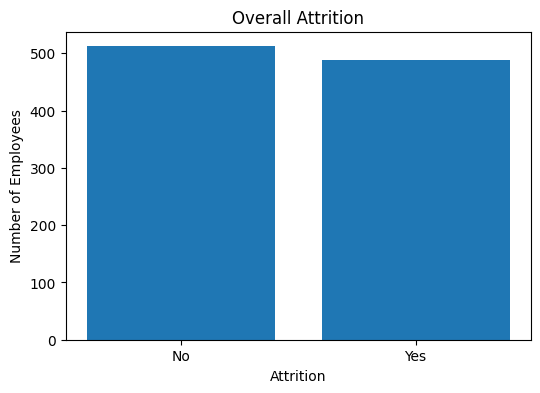

In [75]:
# count overall Attrition
Attrition_count = df["Attrition"].value_counts()

plt.figure(figsize = (6,4))
plt.bar(Attrition_count.index , Attrition_count.values)
plt.title("Overall Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()
           

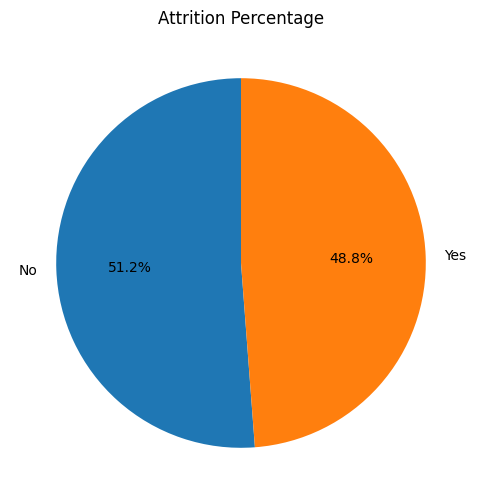

In [76]:
# Attrition percentage
Attrition_percentage = df["Attrition"].value_counts()

plt.figure(figsize = (6,6))
plt.pie(
    Attrition_percentage,
    labels = Attrition_percentage.index,
    autopct = '%1.1f%%',
    startangle = 90
)
plt.title("Attrition Percentage")
plt.show()

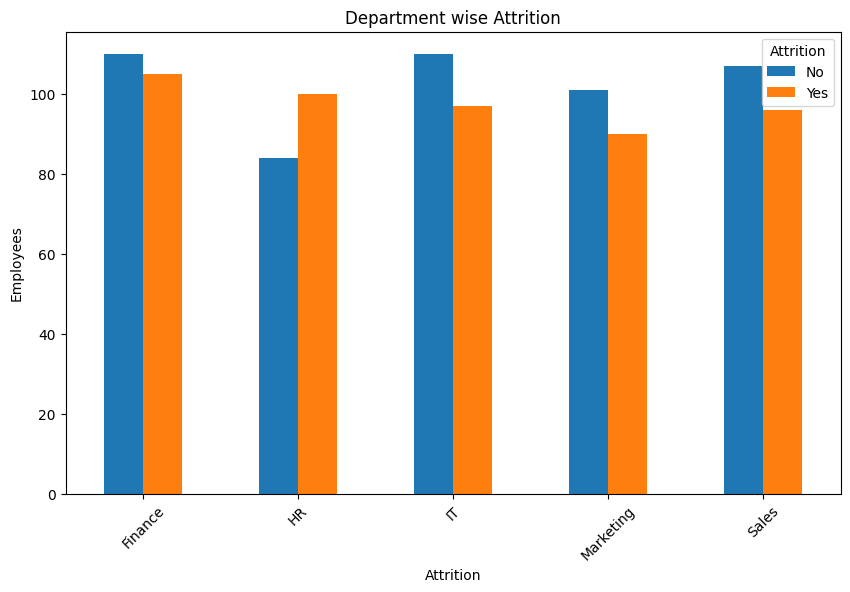

In [80]:
# Department wise Attrition
Dept_Attrition = df.groupby(["Department","Attrition"]).size().unstack()

Dept_Attrition.plot(kind='bar',figsize=(10,6))

plt.title("Department wise Attrition")
plt.xlabel("Attrition")
plt.ylabel("Employees")
plt.xticks(rotation=45)
plt.show()

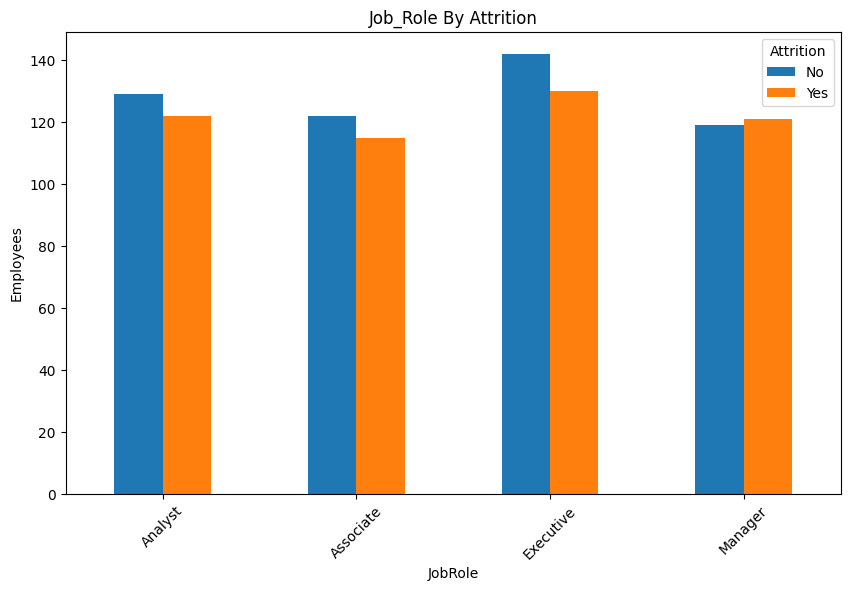

In [83]:
Job_Attrition = df.groupby(['JobRole','Attrition']).size().unstack()

Job_Attrition.plot(kind='bar',figsize=(10,6))

plt.title("Job_Role By Attrition")
plt.xlabel("JobRole")
plt.ylabel("Employees")
plt.xticks(rotation=45)
plt.show()

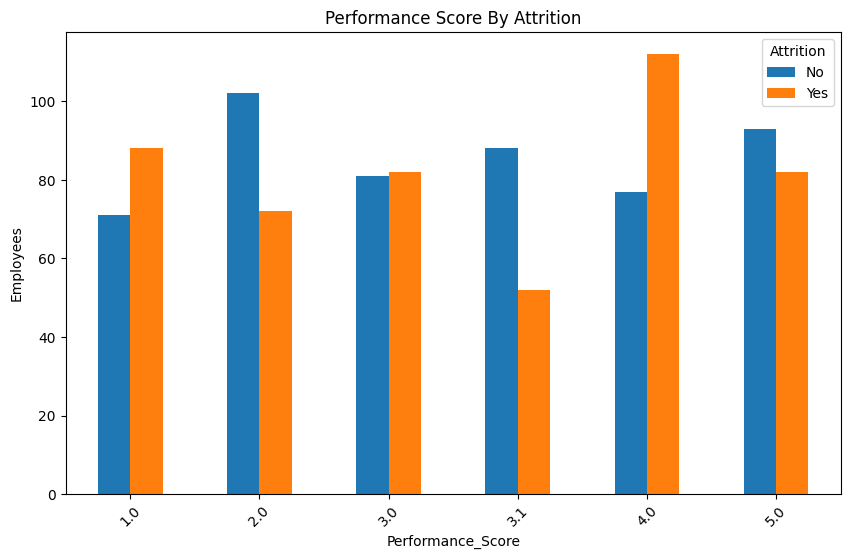

In [91]:
# performance Score vs Attrition
Performance_score = df.groupby(['PerformanceScore','Attrition']).size().unstack()

Performance_score.plot(kind='bar',figsize=(10,6))

plt.title("Performance Score By Attrition")
plt.xlabel("Performance_Score")
plt.ylabel("Employees")
plt.xticks(rotation=45)
plt.show()

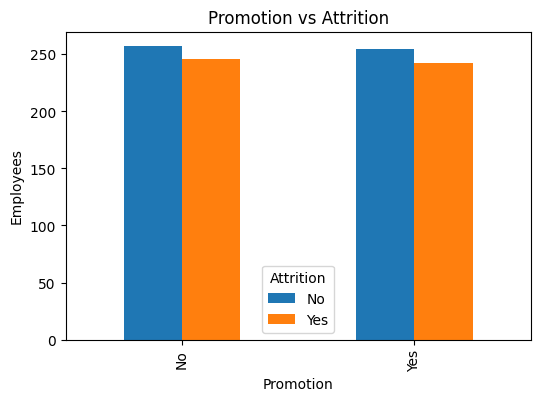

In [86]:
# promotion vs Attrition
promotion = df.groupby(['Promotion','Attrition']).size().unstack()

promotion.plot(kind='bar', figsize=(6,4))

plt.title("Promotion vs Attrition")
plt.xlabel("Promotion")
plt.ylabel("Employees")
plt.show()

C:\Users\sidvi\AppData\Local\Temp\ipykernel_11204\522081698.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([yes_salary, no_salary],


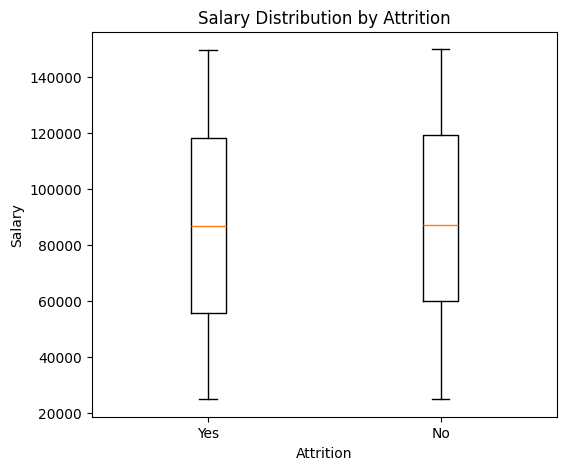

In [87]:
# salary distribution by Attrition
yes_salary = df[df['Attrition']=='Yes']['Salary']
no_salary = df[df['Attrition']=='No']['Salary']

plt.figure(figsize=(6,5))
plt.boxplot([yes_salary, no_salary],
            labels=['Yes','No'])

plt.title("Salary Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Salary")
plt.show()

C:\Users\sidvi\AppData\Local\Temp\ipykernel_11204\543059942.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([yes_training, no_training],


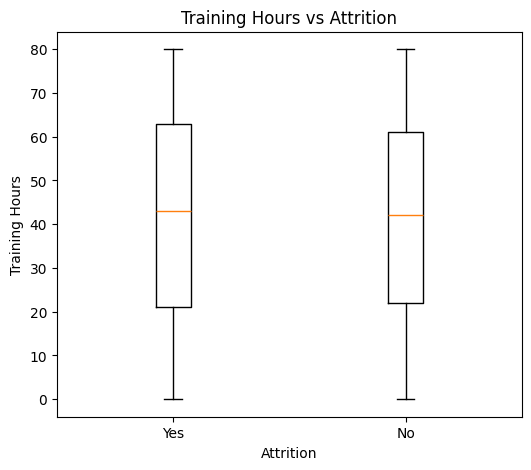

In [88]:
# training hours vs Attrition
yes_training = df[df['Attrition']=='Yes']['TrainingHours']
no_training = df[df['Attrition']=='No']['TrainingHours']

plt.figure(figsize=(6,5))
plt.boxplot([yes_training, no_training],
            labels=['Yes','No'])

plt.title("Training Hours vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Training Hours")
plt.show()